In [ ]:
suppressMessages({
library(BayesSpace)
library(SingleCellExperiment)
library(ggplot2)
library(Seurat)
library(cowplot)
library(RColorBrewer)
library(getopt)
library(ComplexHeatmap)
library(viridis)
library(future)
library(dplyr)
library(Matrix)
library(data.table)
library(reshape2)
    
# library(imager)
library(RColorBrewer)
library(Seurat)
library(ggplot2)
library(tidyverse)
})

cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
cols = c(cols,cols)


In [3]:
counts <-data.table::fread( '/data/work/06.public/06.GSE186538/GSE186538_Human_counts.mtx.gz' ,header=T)
genes = data.table::fread( '/data/work/06.public/06.GSE186538/GSE186538_Human_genes.txt.gz' ,header=F)
meta = data.table::fread( '/data/work/06.public/06.GSE186538/GSE186538_Human_cell_meta.txt.gz' ,header=T)
# gene[1:3,]

In [6]:
rds = Read10X('/data/work/08.脑区划分/02.result/03.sn/01.GSE186538/00.10Xmatrix_files',gene.column=1)

In [7]:
rds = Read10X('/data/users/liuyuyang/online/08.脑区划分/02.result/03.sn/01.GSE186538/00.10Xmatrix_files',gene.column=1)

obj <- CreateSeuratObject(
  counts = rds,
  project = "SingleCell"
)

obj@meta.data$samplename = meta$samplename[match(row.names(obj@meta.data),meta$cell_name  )]
obj@meta.data$region = meta$region[match(row.names(obj@meta.data),meta$cell_name  )]
obj@meta.data$cluster = meta$cluster[match(row.names(obj@meta.data),meta$cell_name  )]

In [46]:
obj@meta.data$samplename = meta$samplename[match(row.names(obj@meta.data),meta$cell_name  )]
obj@meta.data$region = meta$region[match(row.names(obj@meta.data),meta$cell_name  )]
obj@meta.data$cluster = meta$cluster[match(row.names(obj@meta.data),meta$cell_name  )]
obj@meta.data[1:3,]

,orig.ident,nCount_RNA,nFeature_RNA,samplename,region,cluster
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>
HSB179_1_eDG_ACCTACCTCGAGAACG,HSB179,50210,7161,HSB179,DG,CA3 CFAP299 SYN3
HSB179_1_eDG_ACCTGTCGTATCCCTC,HSB179,88088,8943,HSB179,DG,CA3 CFAP299 SYN3
HSB179_1_eDG_ACGGAAGTCTTACTGT,HSB179,63894,9548,HSB179,DG,CA3 CFAP299 SYN3


In [51]:
obj$region1 = gsub(' .*$','',obj$cluster)

In [58]:
obj$del = 'no'
obj@meta.data[which( (obj$region == 'EC')&(obj$region1 %in% c('CA1','CA2','CA3','DG','SUB') ) ),'del'] = 'yes'
obj@meta.data[which( (obj$region == 'CA1')&(obj$region1  %in% c('EC','CA2','CA3','DG','SUB')) ),'del'] = 'yes'
obj@meta.data[which( (obj$region == 'DG')&(obj$region1 %in% c('CA1','CA2','CA3','EC','SUB')) ),'del'] = 'yes'
obj@meta.data[which( (obj$region == 'SUB')&(obj$region1  %in% c('CA1','CA2','CA3','DG','EC')) ),'del'] = 'yes'
obj@meta.data[which( (obj$region == 'CA24')&(obj$region1  %in% c('CA1','DG','EC','SUB')) ),'del'] = 'yes'

# obj@meta.data[which( (obj$region == 'CA24')&(obj$region1 != 'EC') ),'del'] = 'yes'

In [52]:
table(obj$region,obj$region1)

      
       aEndo  aSMC Astro   CA1   CA2   CA3   COP    CR    DG    EC  Endo   InN
  CA1     31   100  3445  2876     0     2    22     8   192    48   386  1152
  CA24     2    16  2617   288    67  1034    23     2  1710     1   379   588
  DG      83   261 17208    75    41  3190   202    10 32500    14  1874  6397
  EC      46   156  3874    11     0     0    34    10     6  9857   396  3896
  SUB      7    39  2650  1947     0     3    47     1    43    54   423  1509
      
       Macro Micro Myeloid Oligo   OPC    PC   SUB     T  VLMC  vSMC
  CA1     52  3066      16  5011  1796    77    63   116   114   102
  CA24    23  1570       6  4873  1550   125    27    30    37    55
  DG     126  8020      18 55794 11989   368     3   226   392   396
  EC      35  1598      13  4727  2488    55     2    36    91   116
  SUB     37  2202      14  5286  2276   117  1834    71    45   121

In [59]:
seuobj = subset(obj,del == 'no')

In [60]:
table(seuobj$region,seuobj$region1)

      
       aEndo  aSMC Astro   CA1   CA2   CA3   COP    CR    DG    EC  Endo   InN
  CA1     31   100  3445  2876     0     0    22     8     0     0   386  1152
  CA24     2    16  2617     0    67  1034    23     2     0     0   379   588
  DG      83   261 17208     0     0     0   202    10 32500     0  1874  6397
  EC      46   156  3874     0     0     0    34    10     0  9857   396  3896
  SUB      7    39  2650     0     0     0    47     1     0     0   423  1509
      
       Macro Micro Myeloid Oligo   OPC    PC   SUB     T  VLMC  vSMC
  CA1     52  3066      16  5011  1796    77     0   116   114   102
  CA24    23  1570       6  4873  1550   125     0    30    37    55
  DG     126  8020      18 55794 11989   368     0   226   392   396
  EC      35  1598      13  4727  2488    55     0    36    91   116
  SUB     37  2202      14  5286  2276   117  1834    71    45   121

In [62]:
saveRDS(seuobj,'sn.allcells.del_false_cell.merge.rds')
getwd()

[1] "/data/work/08.脑区划分/04_BrainPathology260409"

In [11]:
zzm60colors <- c('#4b6aa8','#3ca0cf','#c376a7','#ad98c3','#cea5c7',
                 '#53738c','#a5a9b0','#a78982','#696a6c','#92699e',
                 '#d69971','#df5734','#6c408e','#ac6894','#d4c2db',
                 '#537eb7','#83ab8e','#ece399','#405993','#cc7f73',
                 '#b95055','#d5bb72','#bc9a7f','#e0cfda','#d8a0c0',
                 '#e6b884','#b05545','#d69a55','#64a776','#cbdaa9',
                 '#efd2c9','#da6f6d','#ebb1a4','#a44e89','#a9c2cb',
                 '#b85292','#6d6fa0','#8d689d','#c8c7e1','#d25774',
                 '#c49abc','#927c9a','#3674a2','#9f8d89','#72567a',
                 '#63a3b8','#c4daec','#61bada','#b7deea','#e29eaf',
                 '#4490c4','#e6e2a3','#de8b36','#c4612f','#9a70a8',
                 '#76a2be','#408444','#c6adb0','#9d3b62','#2d3462')

In [2]:
seuobj = readRDS('sn.allcells.del_false_cell.merge.rds')

In [3]:
need_cluster = 
c('SUB distal FN1 NTNG1', #############
'DG GC PROX1 PDLIM5','DG GC PROX1 SGCZ',
'DG MC ARHGAP24 DLC1',
'CA3 CFAP299 SYN3',
'CA2 CFAP299 HGF',
'CA1 dorsal GRIK1 GRM3',
'CA1 ventral ACVR1C SYT13',
'SUB proximal ROBO1 COL5A2',
'EC L2 CUX2 PDGFD',
'EC L2 CUX2 LAMA3',
'EC L2 CUX2 CALB1',
'EC L2 CUX2 IL1RAPL2',
'EC L3 PCP4 ADARB2',
'EC L5 RORB TLL1',
'EC L6 THEMIS CDH13',
'EC L5 RORB TPBG',
'EC L6 THEMIS RGS12',
'EC L2 RELN BCL11B',
'EC L2 RELN BMPR1B',

'EC L5 BCL11B ADRA1A',
'EC L56 TLE4 NXPH2',
'SUB proximal ROBO1 SEMA3E',
'EC L6 TLE4 SULF1',
'EC L6b TLE4 CCN2',
'CR RELN NDNF',
'InN MEIS2 SHISAL2B',
'InN SST NPY',
'InN SST ADAMTS12',
'InN SST EPB41L4A',
'InN SST OTOF',
'InN PVALB PLEKHH2',
'InN LHX6 AC008415.1',
'InN PVALB MEPE',
'InN PVALB PLCL1',
'InN VIP NOX4',
'InN VIP SCTR',
'InN VIP ABI3BP',
'InN VIP SCML4',
'InN VIP CHRNA2',
'InN VIP PENK',
'InN NR2F2 PTPRK',
'InN NR2F2 MIR4300HG',
'InN NR2F2 SLC17A8',
'InN NR2F2 ANO2',
'InN NR2F2 DDR2','InN LAMP5 CHST9','InN LAMP5 KIT','InN LAMP5 NMBR')



In [4]:
seuobj = subset(seuobj,cluster %in% need_cluster )

In [5]:
DefaultAssay(seuobj) = "RNA"
print("RunPCA-NormalizeData")
seuobj <- NormalizeData(seuobj) %>% FindVariableFeatures(nfeatures=3000) %>% ScaleData() %>% RunPCA(verbose=FALSE)
print("RunPCA-NormalizeData.okk")
# seuobj <- RunHarmony(seuobj, group.by.vars = "samplename")
pc.num=1:30
seuobj <- FindNeighbors(seuobj,reduction = "pca", dims = pc.num)
seuobj <- FindClusters(seuobj,resolution = 0.5 )
print("RunUMAP.start")
seuobj <- RunUMAP(seuobj,reduction = "pca", dims = pc.num)


[1] "RunPCA-NormalizeData"


Centering and scaling data matrix



[1] "RunPCA-NormalizeData.okk"


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 61741
Number of edges: 2239545

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9614
Number of communities: 27
Elapsed time: 20 seconds
[1] "RunUMAP.start"


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
13:45:26 UMAP embedding parameters a = 0.9922 b = 1.112

13:45:26 Read 61741 rows and found 30 numeric columns

13:45:26 Using Annoy for neighbor search, n_neighbors = 30

13:45:26 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:45:32 Writing NN index file to temp file /tmp/RtmppxnB9l/filedb766d537d

13:45:32 Searching Annoy index using 1 thread, search_k = 3000

13:45:50 Annoy recall = 100%

13:45:52 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

In [6]:
seuobj <- RunUMAP(seuobj,reduction = "pca", dims = pc.num)


13:50:05 UMAP embedding parameters a = 0.9922 b = 1.112

13:50:05 Read 61741 rows and found 30 numeric columns

13:50:05 Using Annoy for neighbor search, n_neighbors = 30

13:50:05 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:50:11 Writing NN index file to temp file /tmp/RtmppxnB9l/filedb11123c51

13:50:11 Searching Annoy index using 1 thread, search_k = 3000

13:50:28 Annoy recall = 100%

13:50:29 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

13:50:33 Initializing from normalized Laplacian + noise (using irlba)

13:53:14 Commencing optimization for 200 epochs, with 2663052 positive edges

13:54:30 Optimization finished



In [ ]:
seuobj$cell_type = 'EX'
seuobj$cell_type[grepl('^InN',seuobj$cell_type)==TRUE] = 'IN'

In [ ]:
seuobj$celltype = gsub(' .*$','',seuobj$cluster)
seuobj$celltype[which(seuobj$celltype != 'InN')] = 'ExN'
table(seuobj$celltype)



  ExN   InN 
48199 13542 

In [17]:
p4 = DimPlot(seuobj, reduction = "umap", group.by='celltype',cols = c('#FFC470','#DD5746'),raster = TRUE )
ggsave('02.sn.del_Glial.umap.by_EX_IN.png',p4,width = 7,height = 7)
ggsave('02.sn.del_Glial.umap.by_EX_IN.pdf',p4,width = 7,height = 7)

In [18]:
cols = c('#c1232b','#e87c25','#27727b','#0FB56D','#60c0dd')
names(cols) = c('SUB',"CA1",'CA24','EC','DG')

options(repr.plot.width = 10,repr.plot.height = 7)
p2 = DimPlot(seuobj, reduction = "umap", group.by='region',cols = cols,raster = TRUE)
ggsave('02.umap.region.pdf',p2,width = 7,height = 7)
ggsave('02.umap.region.png',p2,width = 7,height = 7)


In [19]:
best_color <- c("#7974da", "#90d42d", "#ff8b7b",  "#61a946", "#02bdfe", "#0068af", "#fd7c01","#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A", "#B15928","#FBB4AE", 
                "#B3CDE3", "#BC80BD", "#CCEBC5", "#DECBE4", "#FED9A6","#FFFFCC", "#E5D8BD", "#FDDAEC", "#F2F2F2", "#B3E2CD", "#FDCDAC","#CBD5E8", "#F4CAE4", "#E6F5C9", 
                "#FFF2AE", "#F1E2CC", "#CCCCCC","#E41A1C", "#377EB8", "#984EA3", "#FFFF33", "#A65628", "#F781BF","#999999", "#FFED6F", "#66C2A5", "#FC8D62", "#8DA0CB", 
                "#E78AC3","#A6D854", "#FFD92F", "#E5C494", "#B3B3B3", "#8DD3C7", "#FFFFB3","#BEBADA", "#FB8072", "#80B1D3", "#FDB462", "#B3DE69", "#FCCDE5","#D9D9D9","#666666")

p2 = DimPlot(seuobj, reduction = "umap", group.by='cluster',cols = best_color,raster = TRUE)
ggsave('02.umap.cluster.pdf',p2,width = 14,height = 7)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


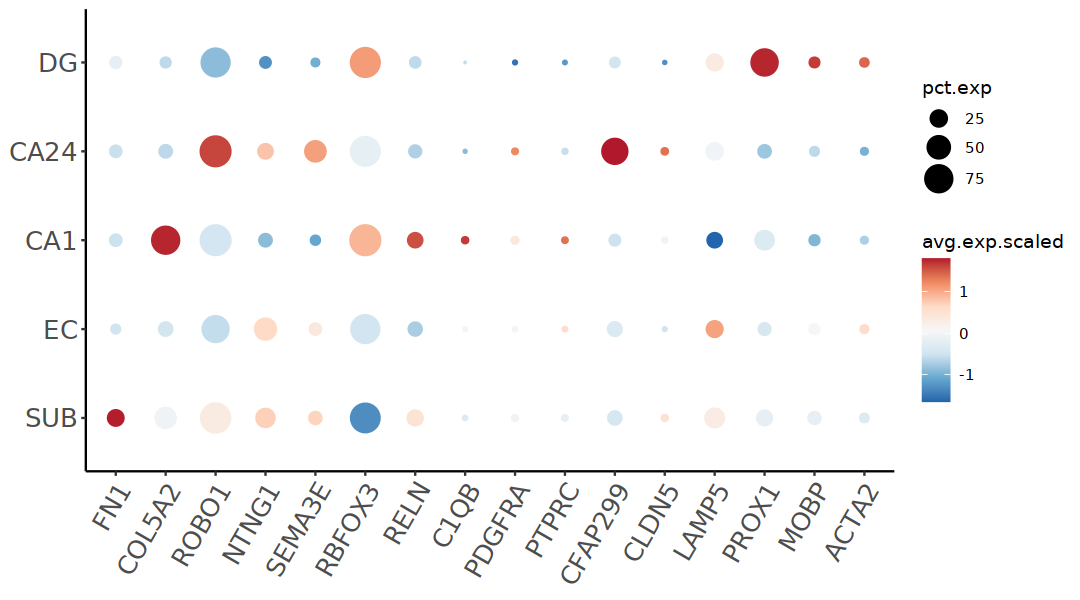

In [26]:
# marker = c("FN1",'ROBO1','COL5A2','NTNG1','SEMA3E',
#            "RBFOX3","RELN","C1QB","PDGFRA","PTPRC","SLC17A7",
#            "CFAP299","CLDN5","LAMP5","AQP4","PROX1","MOBP","ACTA2")
#            # "CUX2","RORB","GAD1","GAD2","MEIS2","LHX6","SST","PVALB","VIP","NR2F2","CEMIP") 
marker = c("FN1",'ROBO1','COL5A2','NTNG1','SEMA3E',
           "RBFOX3","RELN","C1QB","PDGFRA","PTPRC",
           "CFAP299","CLDN5","LAMP5","PROX1","MOBP","ACTA2")

Idents(seuobj)="region"
DefaultAssay(seuobj)="RNA"
p = DotPlot(seuobj, features = marker,idents = c('SUB','EC','CA1','CA24','DG') )+coord_flip()+
  theme_bw()+
  theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60))+
  labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))+
    scale_color_gradientn(colors = rev(brewer.pal(7, "RdBu")) )# c('#330066','#336699','#66CC66','#FFCC33'))+
df = p$data
df$features.plot = factor(df$features.plot,levels =  c("FN1",'COL5A2','ROBO1','NTNG1','SEMA3E',
                                                       "RBFOX3","RELN","C1QB","PDGFRA","PTPRC",
                                                       "CFAP299","CLDN5","LAMP5","PROX1","MOBP","ACTA2"))
                                                       # "CUX2","RORB","GAD1","GAD2","MEIS2","LHX6","SST","PVALB","VIP","NR2F2","CEMIP")  )
df$id = factor(df$id,levels = c('SUB','EC','CA1','CA24','DG') )
p=ggplot(df, aes(x = id, y = features.plot)) + coord_flip()+
    geom_point(aes(color = avg.exp.scaled, size = pct.exp)) + scale_size_continuous(range=c(0.05,8))+
    scale_color_gradientn(colors = rev(brewer.pal(7, "RdBu")) )+# c('#330066','#336699','#66CC66','#FFCC33'))+
    # scale_fill_gradient(low="purple",high="yellow")+
    theme_classic()+
    theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60,size=15),axis.text.y=element_text(size=15))+
    labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))

options(repr.plot.width = 9,repr.plot.height = 5)
p

In [27]:
ggsave('all_region.marker_dot1.pdf',p,width = 8,height = 4)
getwd()

[1] "/data/work/08.脑区划分/04_BrainPathology260409"

### CA1 SUB脑区

In [3]:
seuobj = readRDS('/data/work/08.脑区划分/02.result/03.sn/01.GSE186538/01.GSE186538_sn.no_harmony.rds')

In [10]:
seuobj@meta.data[1,]

,orig.ident,nCount_RNA,nFeature_RNA,samplename,region,cluster,RNA_snn_res.0.5,seurat_clusters,celltype
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>
HSB179_1_eDG_ACCTACCTCGAGAACG,HSB179,50210,7161,HSB179,DG,CA3 CFAP299 SYN3,10,10,ExN


In [11]:
table(seuobj$region)


  CA1  CA24    DG   SUB 
 4341  3717 42230  5391 

In [12]:
seuobj = subset(seuobj,region %in% c('CA1','SUB') )

In [13]:
counts=seuobj@assays$RNA@counts
meta=seuobj@meta.data
seu_new = CreateSeuratObject(counts,
                             assay = "RNA",
                             meta.data = meta)

In [25]:
seuobj = seu_new

DefaultAssay(seuobj) = "RNA"
print("RunPCA-NormalizeData")
seuobj <- NormalizeData(seuobj) %>% FindVariableFeatures(nfeatures=3000) %>% ScaleData() %>% RunPCA(verbose=FALSE)
print("RunPCA-NormalizeData.okk")
seuobj <- RunHarmony(seuobj, group.by.vars = "samplename")
pc.num=1:30
seuobj <- FindNeighbors(seuobj,reduction = "harmony", dims = pc.num)
seuobj <- FindClusters(seuobj,resolution = 0.5 )
print("RunUMAP.start")

[1] "RunPCA-NormalizeData"


Centering and scaling data matrix



[1] "RunPCA-NormalizeData.okk"


Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10

Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.RNA.harmony; see ?make.names for more details on syntax validity”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9732
Number of edges: 354644

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9182
Number of communities: 18
Elapsed time: 1 seconds
[1] "RunUMAP.start"


20:33:47 UMAP embedding parameters a = 0.9922 b = 1.112

20:33:47 Read 9732 rows and found 30 numeric columns

20:33:47 Using Annoy for neighbor search, n_neighbors = 30

20:33:47 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:33:48 Writing NN index file to temp file /tmp/RtmpEhEBjI/file21a218ff32a

20:33:48 Searching Annoy index using 1 thread, search_k = 3000

20:33:51 Annoy recall = 100%

20:33:52 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

20:33:54 Initializing from normalized Laplacian + noise (using irlba)

20:34:29 Commencing optimization for 500 epochs, with 404382 positive edges

20:35:04 Optimization finished



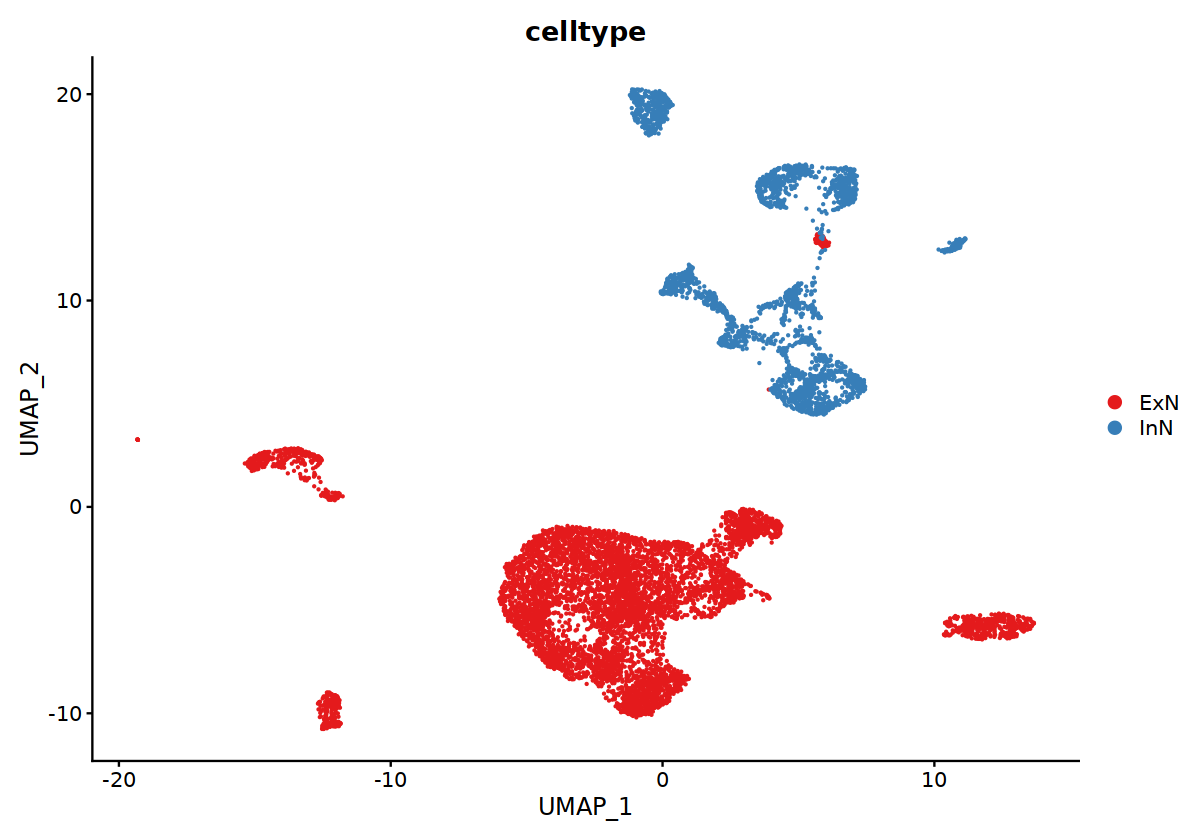

In [26]:
seuobj <- RunUMAP(seuobj,reduction = "harmony", dims = pc.num)
DimPlot(seuobj, reduction = "umap", group.by='celltype',cols = cols)

In [6]:
seuobj = readRDS('/data/work/08.脑区划分/03_返修V1_250709/03_Result/sn.CA1_Sub..harmony.UMAP.251023use.rds')

In [7]:
head(seuobj@meta.data,2)

,orig.ident,nCount_RNA,nFeature_RNA,samplename,region,cluster,RNA_snn_res.0.5,seurat_clusters,celltype,umap_x,umap_y
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>,<dbl>,<dbl>
HSB231_1_CA1_AAACCCACAGTGTGGA,HSB231,22240,5414,HSB231,CA1,CA1 ACVR1C GRIK1,3,3,ExN,-7.898522,0.154117
HSB231_1_CA1_AAACCCACATTGAGGG,HSB231,20916,5643,HSB231,CA1,CA1 ACVR1C GRIK1,1,1,ExN,-2.453588,-3.065870


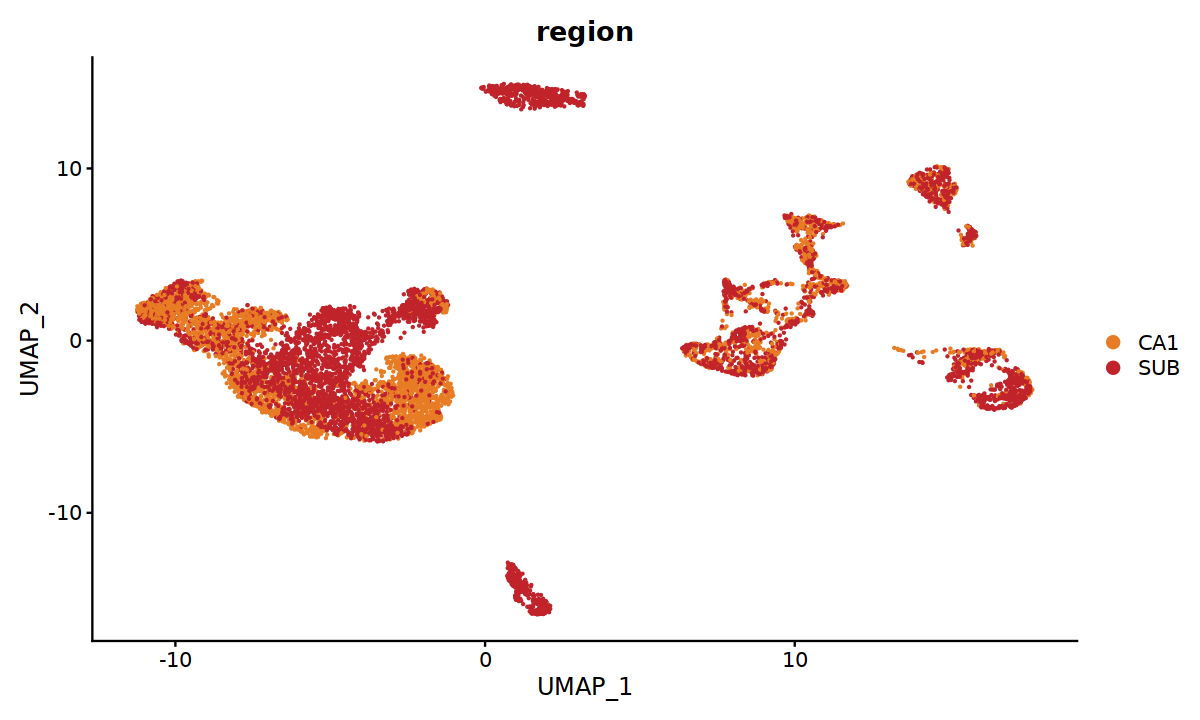

In [8]:
options(repr.plot.width = 10,repr.plot.height = 6)
DimPlot(seuobj, reduction = "umap", group.by='region',cols = acols)

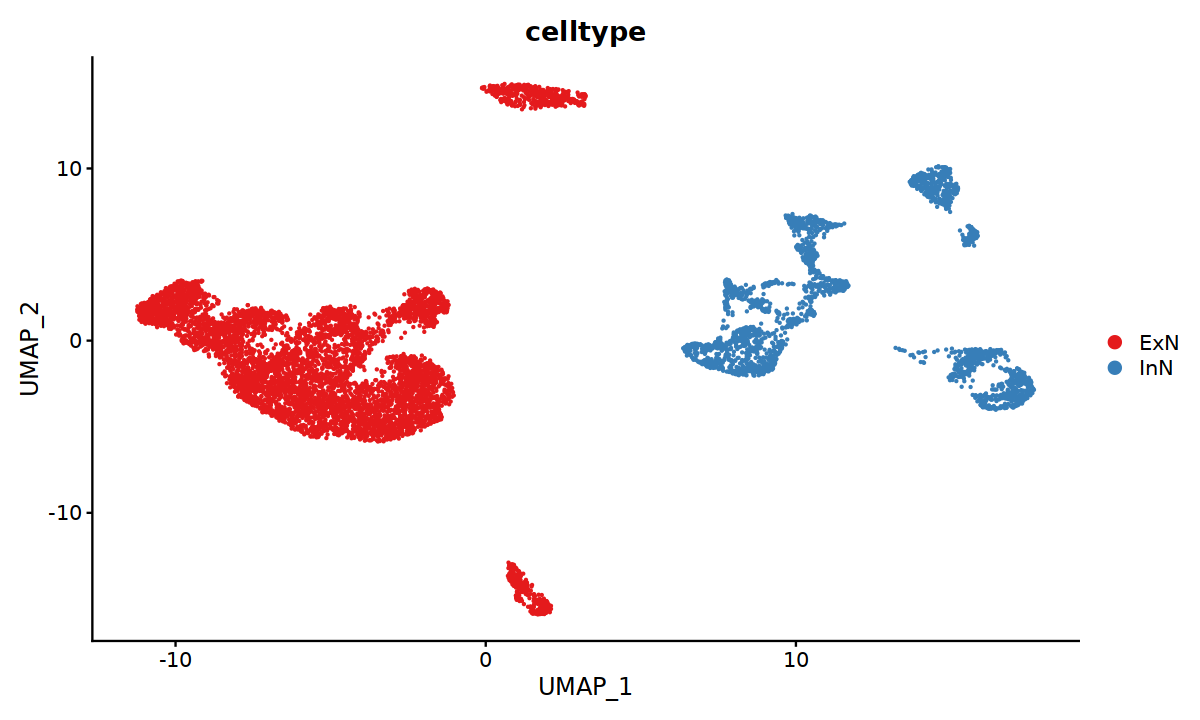

In [9]:
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
cols = c(cols,cols)

options(repr.plot.width = 10,repr.plot.height = 6)
p = DimPlot(seuobj, reduction = "umap", group.by='celltype',cols = cols)
p
ggsave('/data/work/08.脑区划分/03_返修V1_250709/03_Result/01_sn/CA1_Sub.EX_IN.UMAP.pdf',p,width = 7,height = 6)

In [12]:
options(repr.plot.width = 15,repr.plot.height = 6)
p2 = DimPlot(seuobj, reduction = "umap", group.by='cluster',cols = cols)
ggsave('/data/work/08.脑区划分/03_返修V1_250709/03_Result/01_sn/CA1_Sub.cluster.UMAP.pdf',p2,width = 8,height = 6)

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


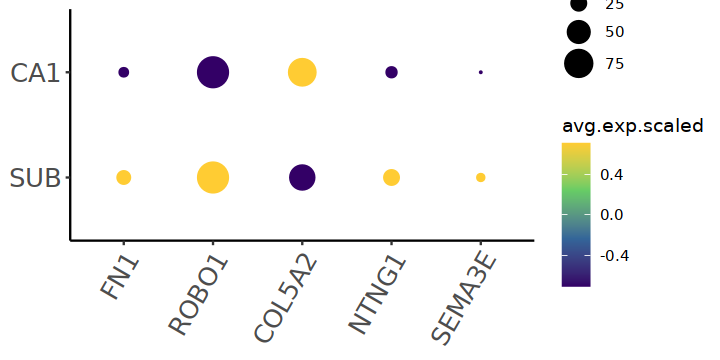

In [43]:
# marker = c("FN1",'ROBO1','COL5A2','NTNG1','SEMA3E',
#            "RBFOX3","RELN","C1QB","PDGFRA","PTPRC","SLC17A7",
#            "CFAP299","CLDN5","LAMP5","AQP4","PROX1","MOBP","ACTA2")
#            # "CUX2","RORB","GAD1","GAD2","MEIS2","LHX6","SST","PVALB","VIP","NR2F2","CEMIP") 
marker = c("FN1",'ROBO1','COL5A2','NTNG1','SEMA3E')
           # "RBFOX3","RELN","C1QB","PDGFRA","PTPRC",
           # "CFAP299","CLDN5","LAMP5","PROX1","MOBP","ACTA2")

Idents(seuobj)="region"
DefaultAssay(seuobj)="RNA"
p = DotPlot(seuobj, features = marker,idents = c('SUB','CA1') )+coord_flip()+
  theme_bw()+
  theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60))+
  labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))+
  scale_color_gradientn(values = seq(0,1,0.2),colours = c('#330066','#336699','#66CC66','#FFCC33'))
df = p$data
df$features.plot = factor(df$features.plot,levels =  c("FN1",'ROBO1','COL5A2','NTNG1','SEMA3E') )
                                                       # "RBFOX3","RELN","C1QB","PDGFRA","PTPRC",
                                                       # "CFAP299","CLDN5","LAMP5","PROX1","MOBP","ACTA2"))
                                                       # "CUX2","RORB","GAD1","GAD2","MEIS2","LHX6","SST","PVALB","VIP","NR2F2","CEMIP")  )
df$id = factor(df$id,levels = c('SUB','CA1') )
p=ggplot(df, aes(x = id, y = features.plot)) + coord_flip()+
    geom_point(aes(color = avg.exp.scaled, size = pct.exp)) + scale_size_continuous(range=c(0.05,8))+
    scale_color_gradientn(colors = c('#330066','#336699','#66CC66','#FFCC33'))+
    # scale_fill_gradient(low="purple",high="yellow")+
    theme_classic()+
    theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 60,size=15),axis.text.y=element_text(size=15))+
    labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))

options(repr.plot.width = 6,repr.plot.height = 3)
p